# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 54     |  |
| :-------------|:-------------|
| Hugo Rutten | 6541593 |
| Thomas Haak| 6472672 |
| Bram Reekers| 6503721 |
| Planning Groep: 54     |Tijdstip / Tijdspanne  |
|---|--|
| Ochtendprogramma af | 12:45 |
| Ontwerp condensator af | 15:00 |
| Metingen klaar | 16:00 |
| groep aanwezig 1| 10:45 |
| groep aanwezig 2| 13:45 |
| Pauze 1| 12:45-13:45 |

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="SchetsenBerekening.jpeg" alt="schets student 1" width="400"/>

In [1]:
epsilon0 = 8.854e-12
def vlakkeplaat(A,d,epsilonr):
    C = (A*epsilon0*epsilonr)/d
    return C

In [2]:
C = vlakkeplaat(0.01,0.005,3)
print(f"Berekende capaciteit plaatcondensator groep 54 is", C*10**12 ,"pF")

Berekende capaciteit plaatcondensator groep 54 is 53.123999999999995 pF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](FotoOpstelling.jpeg)
![scope meting 2](Fotometing.jpeg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 54| 53.125 pF | 0.267 V | 0.270 V | 53.715 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in
![drie schetsen](schetsensensors.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

Pas deze tekst aan: Wij gaan een sensor maken die lengte van voorwerpen meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](uitgewerkdeschets.jpeg)

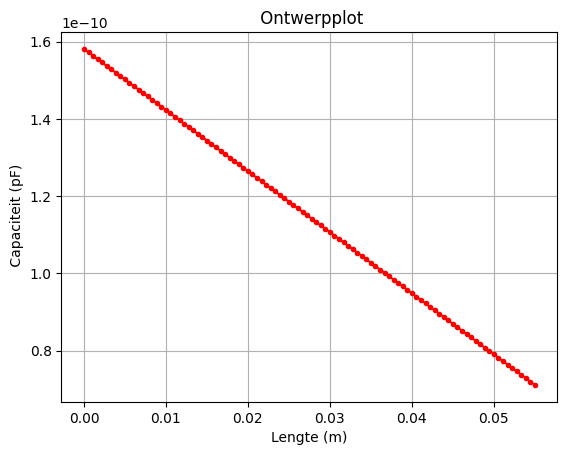

In [3]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
L_min = 0
L_max = 0.055

dikte_karton = 0.00112
breedte = 0.1
epsilon_karton = 2.0

L_array = np.linspace(L_min, L_max, 100)

A_array = breedte * (0.1 - L_array) # de lengte van de overlap is 10 cm - de lengte van het voorwerp\

def ontwerpfunctie(L,dikte,epsilonr):
    L_overlap = 0.1 - L
    C = vlakkeplaat(L_overlap*breedte,dikte,epsilonr)
    return C


plt.figure()
plt.title(" Ontwerpplot")
plt.plot(L_array,ontwerpfunctie(L_array,dikte_karton,epsilon_karton),'r.-')
plt.xlabel("Lengte (m)")
plt.ylabel(" Capaciteit (pF)")
plt.grid()
plt.show()


## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 50 |500 |
| gemiddelde capaciteit| 85 |1003.4 |
| maximale capaciteit| 119 | 1190.9 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](Meetfoto3.jpeg)
![meting 2](Meetfoto4.jpeg)
![meting 3](Meetfoto5.jpeg)
![meting 4](Meetfoto6.jpeg)

## Opdracht 7: Plot de kalibratiegrafiek.

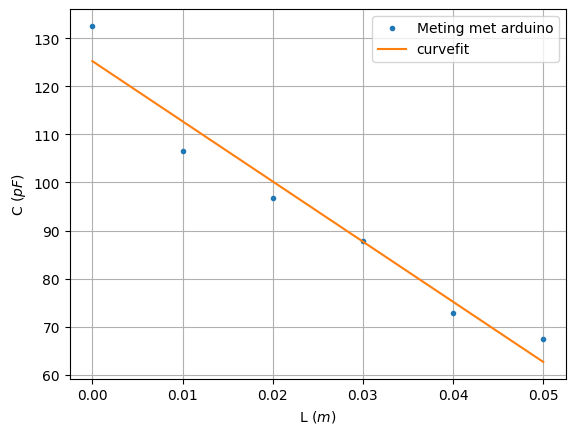

In [4]:
L = np.array([0, 0.01,0.02, 0.03,0.04, 0.05, ])
C = np.array([132.6, 106.5, 96.8, 87.8,72.8, 67.4, ])


popt,pcov = curve_fit(ontwerpfunctie, L, C*10**-12) 

plt.figure()
plt.plot(L,C,'.', label='Meting met arduino')
plt.plot(L,ontwerpfunctie(L,popt[0],popt[1])*10**12,label='curvefit')
plt.xlabel('L $(m)$')
plt.ylabel("C $(pF)$")
plt.legend()
plt.grid()
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* Accuratere meting van de lengte, bijvoorbeeld een schuifmaat
* Op meer punten meten
* De dikte van de tussenlaag verlagen, aangezien een hogere capaciteit zorgt voor meer accuratie.

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](fotosensor.jpeg)

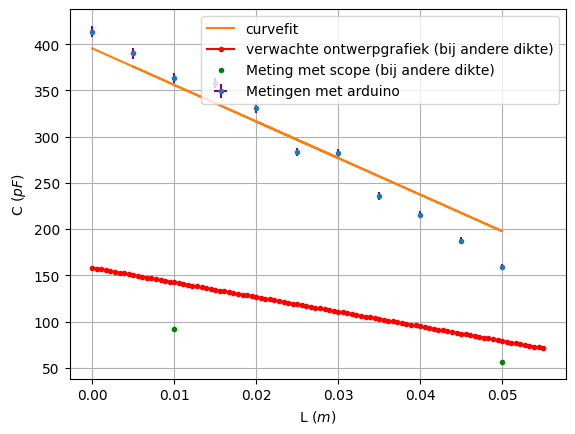

In [5]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.


L = np.array([0,0.01, 0.03, 0.02,0.04,0.05,0.045,0.035,0.025,0.015,0.005])
C = np.array([413.6,363.2,282.6,330.7,215.5,159.3,187.6,235.9,283.5,357.7,390.1 ]) #pF

L_scope = np.array([0.01, 0.05])
C_scope = np.array([92.011, 56.3])


popt,pcov = curve_fit(ontwerpfunctie, L, C*10**-12) 
d = popt[0]
eps = popt[1]
u_d = np.sqrt(pcov[0,0])
u_eps = np.sqrt(pcov[1,1])


C_fit = ontwerpfunctie(L, d, eps)

# b en epsilon0 zijn natuurlijk sterk gerelateerd, dus om toch de onzekerheid van C goed in te schatten vatten we die als
# een parameter op met een onzekerheid
u_combi = np.sqrt(u_d**2 + u_eps**2)

u_C = C_fit * np.sqrt( (u_combi/d)**2 + (u_combi/eps)**2 )

plt.figure()
plt.errorbar(L,C, xerr=0.00001 ,yerr=u_C, fmt='.', ecolor='purple', label="Metingen met arduino") #hierbij is de onzekerheid in de lnget 0.01 mm (digitale schuifmaat)
plt.plot(L,ontwerpfunctie(L,popt[0],popt[1])*10**12,label='curvefit')
plt.plot(L_array, ontwerpfunctie(L_array,dikte_karton,epsilon_karton)*10**12,'r.-',label='verwachte ontwerpgrafiek (bij andere dikte)')
plt.plot(L_scope,C_scope,"g.",label = "Meting met scope (bij andere dikte)")
plt.xlabel('L $(m)$')
plt.ylabel("C $(pF)$")
plt.legend()
plt.grid()
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

De sensor is zeker geschikt om lengtes mee te meten en is daar gevoelig genoeg voor, vanwege de opstelling en gevoeligheid kunnen wel alleen relatief korte lengtes goed gemeten worden (tot ongeveer 6 cm). Na de iteratie konden we exacter de lengtes bepalen en de daarbij passende capaciteit, waardoor de fit beter lukt. Wat ook hielp zijn de hogere waardes voor capaciteit na de iteratie die minder fluctueren, waardoor we die preciezer konden bepalen.
De ontwerpgrafiek is gemaakt bij een andere dikte papier tussen de condensatoren vergeleken met de metingen met de arduino. Uit de metingen met de oscilloscoop (gemaakt met dezelfde dikte papier) kunnen we wel aflezen dat de ontwerpgrafiek er niet heel ver naast zat, toch wijken de resultaten best af. Dit komt voornamelijk doordat we in de meetopstelling te maken hebben met allemaal niet ideale componenten waar we bij de ontwerpgrafiek wel vanuit zijn gaan. Zo is gebleken dat de onderlinge afstand van de kabels al iets is wat een grote invloed kan hebben op de capaciteit. De vlakkeplaat formule voldoet zeker weten, van grote afwijkingen als gevolg van de aanname is er niet echt sprake, al helemaal na de iteratie met de dunnere laag papier.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

### Leerdoel 1

#### Ontwerpgrafiek

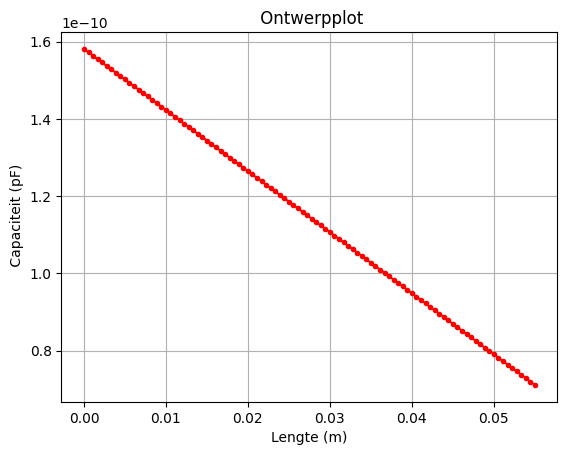

In [6]:
# Plot hier de verwachte ontwerpgrafiek van jullie sensoren
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
L_min = 0
L_max = 0.055

dikte_karton = 0.00112
breedte = 0.1
epsilon_karton = 2.0

L_array = np.linspace(L_min, L_max, 100)

A_array = breedte * (0.1 - L_array) # de lengte van de overlap is 10 cm - de lengte van het voorwerp\

def ontwerpfunctie(L,dikte,epsilonr):
    L_overlap = 0.1 - L
    C = vlakkeplaat(L_overlap*breedte,dikte,epsilonr)
    return C


plt.figure()
plt.title(" Ontwerpplot")
plt.plot(L_array,ontwerpfunctie(L_array,dikte_karton,epsilon_karton),'r.-')
plt.xlabel("Lengte (m)")
plt.ylabel(" Capaciteit (pF)")
plt.grid()
plt.show()


#### Schetsen van onze ideen van sensoren en de uitgewerkte schets

![SchetsenBereking](SchetsenBerekening.jpeg)

![drie schetsen](schetsensensors.jpeg)

![uitgewerkte schets](uitgewerkdeschets.jpeg)



### Leerdoel 2

### Conlusie

De sensor is zeker geschikt om lengtes mee te meten en is daar gevoelig genoeg voor, vanwege de opstelling en gevoeligheid kunnen wel alleen relatief korte lengtes goed gemeten worden (tot ongeveer 6 cm). Na de iteratie konden we exacter de lengtes bepalen en de daarbij passende capaciteit, waardoor de fit beter lukt. Wat ook hielp zijn de hogere waardes voor capaciteit na de iteratie die minder fluctueren, waardoor we die preciezer konden bepalen.
De ontwerpgrafiek is gemaakt bij een andere dikte papier tussen de condensatoren vergeleken met de metingen met de arduino. Uit de metingen met de oscilloscoop (gemaakt met dezelfde dikte papier) kunnen we wel aflezen dat de ontwerpgrafiek er niet heel ver naast zat, toch wijken de resultaten best af. Dit komt voornamelijk doordat we in de meetopstelling te maken hebben met allemaal niet ideale componenten waar we bij de ontwerpgrafiek wel vanuit zijn gaan. Zo is gebleken dat de onderlinge afstand van de kabels al iets is wat een grote invloed kan hebben op de capaciteit. De vlakkeplaat formule voldoet zeker weten, van grote afwijkingen als gevolg van de aanname is er niet echt sprake, al helemaal na de iteratie met de dunnere laag papier.

#### LTSpice tabel

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 50 |500 |
| gemiddelde capaciteit| 85 |1003.4 |
| maximale capaciteit| 119 | 1190.9 |

#### Foto's van sensoren in actie
![meting 1](Meetfoto3.jpeg)
![meting 2](Meetfoto4.jpeg)
![meting 3](Meetfoto5.jpeg)
![meting 4](Meetfoto6.jpeg)

# leerdoel 3

#### Kalibratiegrafiek voor iteratie en verwachte ontwerpgrafiek

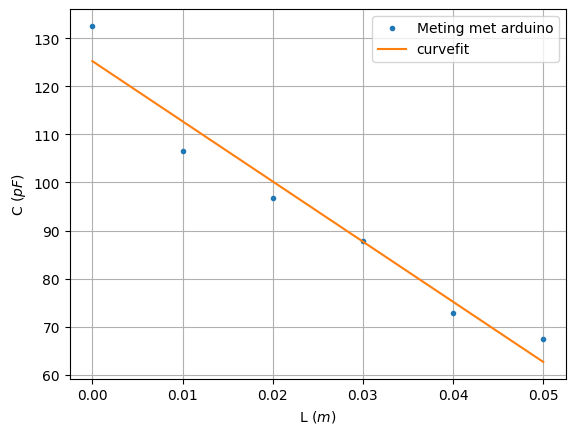

In [7]:
L = np.array([0, 0.01,0.02, 0.03,0.04, 0.05, ])
C = np.array([132.6, 106.5, 96.8, 87.8,72.8, 67.4, ])


popt,pcov = curve_fit(ontwerpfunctie, L, C*10**-12) 

plt.figure()
plt.plot(L,C,'.', label='Meting met arduino')
plt.plot(L,ontwerpfunctie(L,popt[0],popt[1])*10**12,label='curvefit')
plt.xlabel('L $(m)$')
plt.ylabel("C $(pF)$")
plt.legend()
plt.grid()
plt.show()

#### Kalibratiegrafiek na iteratie en verwachte ontwerpgrafiek

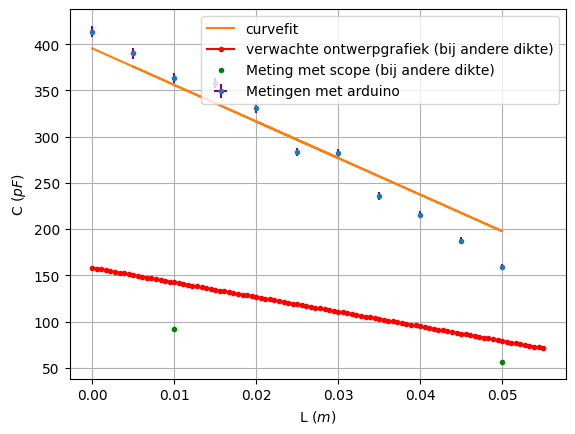

In [8]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafiek.


L = np.array([0,0.01, 0.03, 0.02,0.04,0.05,0.045,0.035,0.025,0.015,0.005])
C = np.array([413.6,363.2,282.6,330.7,215.5,159.3,187.6,235.9,283.5,357.7,390.1 ]) #pF

L_scope = np.array([0.01, 0.05])
C_scope = np.array([92.011, 56.3])


popt,pcov = curve_fit(ontwerpfunctie, L, C*10**-12) 
d = popt[0]
eps = popt[1]
u_d = np.sqrt(pcov[0,0])
u_eps = np.sqrt(pcov[1,1])


C_fit = ontwerpfunctie(L, d, eps)

# b en epsilon0 zijn natuurlijk sterk gerelateerd, dus om toch de onzekerheid van C goed in te schatten vatten we die als
# een parameter op met een onzekerheid
u_combi = np.sqrt(u_d**2 + u_eps**2)

u_C = C_fit * np.sqrt( (u_combi/d)**2 + (u_combi/eps)**2 )

plt.figure()
plt.errorbar(L,C, xerr=0.00001 ,yerr=u_C, fmt='.', ecolor='purple', label="Metingen met arduino") #hierbij is de onzekerheid in de lnget 0.01 mm (digitale schuifmaat)
plt.plot(L,ontwerpfunctie(L,popt[0],popt[1])*10**12,label='curvefit')
plt.plot(L_array, ontwerpfunctie(L_array,dikte_karton,epsilon_karton)*10**12,'r.-',label='verwachte ontwerpgrafiek (bij andere dikte)')
plt.plot(L_scope,C_scope,"g.",label = "Meting met scope (bij andere dikte)")
plt.xlabel('L $(m)$')
plt.ylabel("C $(pF)$")
plt.legend()
plt.grid()
plt.show()

### Conlusie

De sensor is zeker geschikt om lengtes mee te meten en is daar gevoelig genoeg voor, vanwege de opstelling en gevoeligheid kunnen wel alleen relatief korte lengtes goed gemeten worden (tot ongeveer 6 cm). Na de iteratie konden we exacter de lengtes bepalen en de daarbij passende capaciteit, waardoor de fit beter lukt. Wat ook hielp zijn de hogere waardes voor capaciteit na de iteratie die minder fluctueren, waardoor we die preciezer konden bepalen.
De ontwerpgrafiek is gemaakt bij een andere dikte papier tussen de condensatoren vergeleken met de metingen met de arduino. Uit de metingen met de oscilloscoop (gemaakt met dezelfde dikte papier) kunnen we wel aflezen dat de ontwerpgrafiek er niet heel ver naast zat, toch wijken de resultaten best af. Dit komt voornamelijk doordat we in de meetopstelling te maken hebben met allemaal niet ideale componenten waar we bij de ontwerpgrafiek wel vanuit zijn gaan. Zo is gebleken dat de onderlinge afstand van de kabels al iets is wat een grote invloed kan hebben op de capaciteit. De vlakkeplaat formule voldoet zeker weten, van grote afwijkingen als gevolg van de aanname is er niet echt sprake, al helemaal na de iteratie met de dunnere laag papier.